# 📰 Task 2: News Category Classification
## AG News Dataset — Full ML Pipeline

> **Classifying news articles** into 4 categories: **World | Sports | Business | Sci/Tech**

### Pipeline Overview
| Step | Description |
|------|-------------|
| 1️⃣ | Dataset loading (Kaggle AG News CSV) |
| 2️⃣ | Text Preprocessing (tokenize → stopwords → lemmatize) |
| 3️⃣ | TF-IDF Vectorisation (unigrams + bigrams) |
| 4️⃣ | Train 3 classical classifiers (LR, SVM, Random Forest) |
| 5️⃣ | Bonus: Feedforward Neural Network (MLP) |
| 6️⃣ | Evaluation + Visualisations |
| 7️⃣ | Word Clouds per category (Bonus) |

---
### 📦 Kaggle Dataset Setup
**Dataset:** [AG News Classification Dataset](https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset)

**Option A — Kaggle API (recommended in Kaggle notebook):**
```bash
# Already available in Kaggle environment — no download needed!
# Files are at: /kaggle/input/ag-news-classification-dataset/
```

**Option B — Download via Kaggle API locally:**
```bash
pip install kaggle
kaggle datasets download -d amananandrai/ag-news-classification-dataset
unzip ag-news-classification-dataset.zip
```

**Option C — Manual Download:**
1. Go to: https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset
2. Click **Download** → extract the zip
3. Place `train.csv` and `test.csv` in your working directory


## 📦 Step 0 — Install Dependencies & Imports

In [11]:
# Install wordcloud if not present (Kaggle has it pre-installed)
# !pip install wordcloud -q

import warnings, re, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

# Word Cloud (Bonus)
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("wordcloud not installed — skipping word cloud cells")

print("✅ All imports successful!")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")
import sklearn; print(f"   Sklearn : {sklearn.__version__}")


✅ All imports successful!
   Pandas  : 3.0.1
   NumPy   : 2.4.2
   Sklearn : 1.8.0


## 📂 Step 1 — Load AG News Dataset

The AG News dataset contains **120,000 training** and **7,600 test** articles across 4 categories.

| Class ID | Category |
|----------|----------|
| 1 | World |
| 2 | Sports |
| 3 | Business |
| 4 | Sci/Tech |

The CSV files have **no header row** — columns are: `class_index`, `title`, `description`


In [12]:
# ─── Load CSVs ───────────────────────────────────────────────
# Your CSV HAS a header row: "Class Index, Title, Description"
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

# Rename columns to consistent snake_case names
train_df.columns = ["class_index", "title", "description"]
test_df.columns  = ["class_index", "title", "description"]

# class_index is now read correctly as int — no cast needed
# but add this as a safety net just in case
train_df["class_index"] = train_df["class_index"].astype(int)
test_df["class_index"]  = test_df["class_index"].astype(int)

# Combine title + description into one text field
train_df["text"] = train_df["title"] + ". " + train_df["description"]
test_df["text"]  = test_df["title"]  + ". " + test_df["description"]

# Map class index (1-based) → label name
LABEL_MAP = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}
train_df["category_name"] = train_df["class_index"].map(LABEL_MAP)
test_df["category_name"]  = test_df["class_index"].map(LABEL_MAP)

# 0-based labels for sklearn
train_df["label"] = train_df["class_index"] - 1
test_df["label"]  = test_df["class_index"] - 1

print(f"\n📊 Dataset loaded:")
print(f"   Train : {len(train_df):,} articles")
print(f"   Test  : {len(test_df):,}  articles")
print(f"   Total : {len(train_df)+len(test_df):,} articles")
print(f"\n📋 Class distribution (train):")
print(train_df["category_name"].value_counts().to_string())
print(f"\n🔍 Sample article:")
print(f"   Category : {train_df['category_name'].iloc[0]}")
print(f"   Text     : {train_df['text'].iloc[0][:120]}...")


📊 Dataset loaded:
   Train : 120,000 articles
   Test  : 7,600  articles
   Total : 127,600 articles

📋 Class distribution (train):
category_name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000

🔍 Sample article:
   Category : Business
   Text     : Wall St. Bears Claw Back Into the Black (Reuters). Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics...


## 🔍 Step 2 — Exploratory Data Analysis

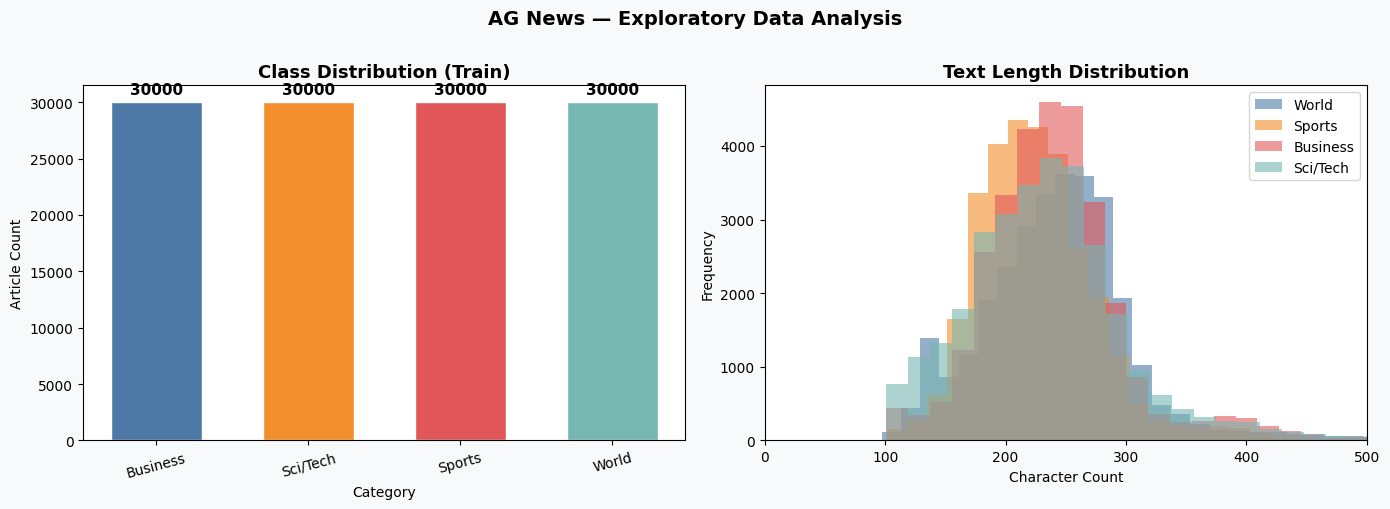


📏 Text Length Statistics:
count    120000.0
mean        237.5
std          66.5
min          18.0
25%         197.0
50%         233.0
75%         267.0
max        1013.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#f8f9fa")
PAL = ["#4e79a7","#f28e2b","#e15759","#76b7b2"]

# ── Class distribution ──────────────────────────────────────
ax = axes[0]
counts = train_df["category_name"].value_counts()
b = ax.bar(counts.index, counts.values, color=PAL, edgecolor="white", width=0.6)
ax.bar_label(b, fmt="%d", padding=4, fontsize=11, fontweight="bold")
ax.set_title("Class Distribution (Train)", fontsize=13, fontweight="bold")
ax.set_ylabel("Article Count"); ax.set_xlabel("Category")
ax.tick_params(axis="x", rotation=15)

# ── Text length distribution ────────────────────────────────
ax = axes[1]
for i, (cat_id, cat_name) in enumerate(LABEL_MAP.items()):
    lengths = train_df.loc[train_df["class_index"]==cat_id, "text"].str.len()
    ax.hist(lengths, bins=50, alpha=0.6, label=cat_name, color=PAL[i])
ax.set_title("Text Length Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Character Count"); ax.set_ylabel("Frequency")
ax.legend()
ax.set_xlim(0, 500)

plt.suptitle("AG News — Exploratory Data Analysis",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Stats ───────────────────────────────────────────────────
print("\n📏 Text Length Statistics:")
print(train_df["text"].str.len().describe().round(1).to_string())


## 🧹 Step 3 — Text Preprocessing

Full NLP pipeline:
1. **Lowercase** all text
2. **Remove** HTML tags, URLs, punctuation & digits
3. **Tokenize** (whitespace split)
4. **Remove stopwords** (sklearn's English stop word list)
5. **Lemmatize** (suffix-stripping rules — no external dependency)


In [14]:
STOP = ENGLISH_STOP_WORDS   # built-in sklearn stopword list

SUFFIX_RULES = [
    ("ational","ate"), ("tional","tion"), ("enci","ence"), ("anci","ance"),
    ("izer","ize"),    ("izing","ize"),   ("ising","ise"), ("ness",""),
    ("ment",""),       ("tion","t"),      ("ies","y"),     ("ing",""),
    ("ed",""),         ("ly",""),         ("er",""),       ("ves","f"),
]

def simple_lemmatize(word: str) -> str:
    if len(word) <= 4:
        return word
    for suffix, rep in SUFFIX_RULES:
        if word.endswith(suffix) and len(word) - len(suffix) >= 3:
            return word[: len(word)-len(suffix)] + rep
    return word

def preprocess(text: str) -> str:
    """
    Full preprocessing pipeline:
    lowercase → strip HTML/URLs → remove non-alpha →
    tokenize → remove stopwords → lemmatize
    """
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)               # HTML tags
    text = re.sub(r"https?://\S+|www\.\S+", " ", text) # URLs
    text = re.sub(r"[^a-z\s]", " ", text)               # punct + digits
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP and len(t) > 2]
    tokens = [simple_lemmatize(t) for t in tokens]
    return " ".join(tokens)

# Apply preprocessing
print("⏳ Preprocessing train set …")
train_df["clean_text"] = train_df["text"].apply(preprocess)
print("⏳ Preprocessing test set …")
test_df["clean_text"]  = test_df["text"].apply(preprocess)

print("\n✅ Preprocessing complete!")
print(f"\n📝 Example:")
print(f"  BEFORE: {train_df['text'].iloc[0][:120]}")
print(f"  AFTER : {train_df['clean_text'].iloc[0][:120]}")


⏳ Preprocessing train set …
⏳ Preprocessing test set …

✅ Preprocessing complete!

📝 Example:
  BEFORE: Wall St. Bears Claw Back Into the Black (Reuters). Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics
  AFTER : wall bears claw black reuters reuters short sellers wall street dwindl band ultra cynics see green


## 🔢 Step 4 — TF-IDF Feature Engineering

**Why TF-IDF?**
- **TF** (Term Frequency): how often a word appears in the article
- **IDF** (Inverse Document Frequency): penalises common words across all articles
- Combined they highlight *distinctive* words per article

**Settings used:**
- `max_features=50,000` — top 50K words by frequency
- `ngram_range=(1,2)` — unigrams AND bigrams (e.g. "artificial intelligence")
- `sublinear_tf=True` — apply log(1+tf) to dampen very frequent terms
- `min_df=2` — ignore words appearing in fewer than 2 documents


In [15]:
X_train_raw = train_df["clean_text"].values
X_test_raw  = test_df["clean_text"].values
y_train     = train_df["label"].values
y_test      = test_df["label"].values

# Fit TF-IDF on training data only (no data leakage!)
tfidf = TfidfVectorizer(
    max_features = 50_000,
    ngram_range  = (1, 2),
    sublinear_tf = True,
    min_df       = 2,
    analyzer     = "word",
)

print("⏳ Fitting TF-IDF vectoriser …")
X_train_tf = tfidf.fit_transform(X_train_raw)
X_test_tf  = tfidf.transform(X_test_raw)

print(f"\n✅ TF-IDF complete!")
print(f"   Train matrix shape : {X_train_tf.shape}")
print(f"   Test  matrix shape : {X_test_tf.shape}")
print(f"   Vocabulary size    : {len(tfidf.vocabulary_):,} features")
print(f"   Matrix sparsity    : {1 - X_train_tf.nnz / (X_train_tf.shape[0]*X_train_tf.shape[1]):.4%}")

# Show top features
feature_names = tfidf.get_feature_names_out()
print(f"\n🔤 Sample features: {list(feature_names[:10])}")
print(f"   ...and bigrams: {[f for f in feature_names if ' ' in f][:8]}")


⏳ Fitting TF-IDF vectoriser …

✅ TF-IDF complete!
   Train matrix shape : (120000, 50000)
   Test  matrix shape : (7600, 50000)
   Vocabulary size    : 50,000 features
   Matrix sparsity    : 99.9483%

🔤 Sample features: ['aaa', 'aapl', 'aapl news', 'aaron', 'aaron peirsol', 'aaron rodgers', 'ababa', 'abandon', 'abandon microsoft', 'abandon nuclear']
   ...and bigrams: ['aapl news', 'aaron peirsol', 'aaron rodgers', 'abandon microsoft', 'abandon nuclear', 'abandon plans', 'abbas said', 'abbey bid']


## 🤖 Step 5 — Train Classifiers

Three classical multiclass classifiers:

| Model | Key Strengths |
|-------|--------------|
| **Logistic Regression** | Fast, interpretable, strong baseline for text |
| **Linear SVM** | Excellent on high-dimensional sparse data (TF-IDF) |
| **Random Forest** | Captures non-linear patterns, robust to noise |


In [16]:
CAT_NAMES = [LABEL_MAP[i+1] for i in range(4)]

classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, C=5, solver="saga", n_jobs=-1),
    "Linear SVM": LinearSVC(C=1.0, max_iter=3000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, n_jobs=-1, random_state=42),
}

results   = {}
reports   = {}
conf_mats = {}

for name, clf in classifiers.items():
    print(f"▶  Training {name} …", end=" ", flush=True)
    clf.fit(X_train_tf, y_train)
    preds = clf.predict(X_test_tf)
    acc   = accuracy_score(y_test, preds)
    results[name]   = acc
    reports[name]   = classification_report(y_test, preds,
                       target_names=CAT_NAMES, output_dict=True)
    conf_mats[name] = confusion_matrix(y_test, preds)
    print(f"Accuracy = {acc:.4f} ✅")

print("\n" + "="*50)
print("  MODEL RESULTS SUMMARY")
print("="*50)
best = max(results, key=results.get)
for m, a in sorted(results.items(), key=lambda x: -x[1]):
    flag = " ◀ BEST" if m == best else ""
    print(f"  {m:<22}  {a:.4f}{flag}")


▶  Training Logistic Regression … Accuracy = 0.9167 ✅
▶  Training Linear SVM … Accuracy = 0.9176 ✅
▶  Training Random Forest … Accuracy = 0.8967 ✅

  MODEL RESULTS SUMMARY
  Linear SVM              0.9176 ◀ BEST
  Logistic Regression     0.9167
  Random Forest           0.8967


## 📊 Step 6 — Detailed Classification Reports

In [17]:
for name, clf in classifiers.items():
    print(f"\n{'─'*52}")
    print(f"  {name}")
    print(f"{'─'*52}")
    print(classification_report(y_test,
          clf.predict(X_test_tf), target_names=CAT_NAMES))



────────────────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────────────────
              precision    recall  f1-score   support

       World       0.93      0.90      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.89      0.88      0.88      1900
    Sci/Tech       0.89      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600


────────────────────────────────────────────────────
  Linear SVM
────────────────────────────────────────────────────
              precision    recall  f1-score   support

       World       0.94      0.90      0.92      1900
      Sports       0.95      0.98      0.97      1900
    Business       0.89      0.88      0.89      1900
    Sci/Tech       0.89      0.90      0.90      1900

    accuracy                           0.92 

## 🧠 Step 7 — Neural Network (Feedforward MLP)  *(Bonus)*

A **Multilayer Perceptron (MLP)** with 3 hidden layers:

```
Input (TF-IDF vector) → Dense(256, ReLU) → Dense(128, ReLU) → Dense(64, ReLU) → Softmax(4)
```

- **Solver:** Adam (adaptive learning rate)
- **Early stopping:** prevents overfitting on validation set
- **Activation:** ReLU for hidden layers, Softmax for output


In [18]:
print("⏳ Training MLP Neural Network …")

mlp = MLPClassifier(
    hidden_layer_sizes = (256, 128, 64),
    activation         = "relu",
    solver             = "adam",
    alpha              = 0.0001,         # L2 regularisation
    max_iter           = 50,
    early_stopping     = True,
    validation_fraction= 0.1,
    n_iter_no_change   = 5,
    random_state       = 42,
    verbose            = False,
)

mlp.fit(X_train_tf, y_train)
nn_preds = mlp.predict(X_test_tf)
nn_acc   = accuracy_score(y_test, nn_preds)

results["MLP Neural Network"]   = nn_acc
reports["MLP Neural Network"]   = classification_report(y_test, nn_preds,
                                   target_names=CAT_NAMES, output_dict=True)
conf_mats["MLP Neural Network"] = confusion_matrix(y_test, nn_preds)

print(f"\n✅ MLP Neural Network Accuracy: {nn_acc:.4f}")
print(f"   Iterations run : {mlp.n_iter_}")
print(f"\n{classification_report(y_test, nn_preds, target_names=CAT_NAMES)}")


⏳ Training MLP Neural Network …

✅ MLP Neural Network Accuracy: 0.2500
   Iterations run : 0

              precision    recall  f1-score   support

       World       0.00      0.00      0.00      1900
      Sports       0.00      0.00      0.00      1900
    Business       0.25      1.00      0.40      1900
    Sci/Tech       0.00      0.00      0.00      1900

    accuracy                           0.25      7600
   macro avg       0.06      0.25      0.10      7600
weighted avg       0.06      0.25      0.10      7600



## 🔄 Step 8 — Cross-Validation (Best Model Validation)

⏳ Running 5-fold cross-validation on Logistic Regression …
   (Using 20% subsample for speed — remove [:24000] for full run)

CV Fold Scores : [0.8735 0.8765 0.8867 0.8869 0.8958]
Mean ± Std     : 0.8839 ± 0.0080


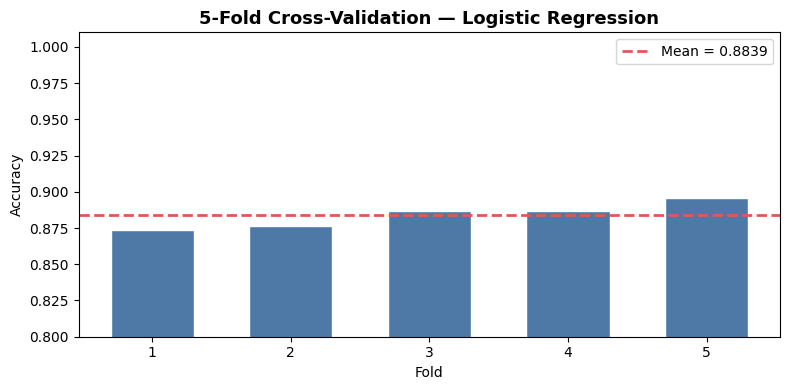

In [ ]:
from sklearn.pipeline import Pipeline

print("⏳ Running 5-fold cross-validation on Logistic Regression …")
print("   (Using 20% subsample for speed — remove [:24000] for full run)\n")

# Subsample for faster CV — remove slice for full dataset
X_cv = train_df["text"].values[:24000]
y_cv = train_df["label"].values[:24000]

pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50_000, ngram_range=(1,2),
                              sublinear_tf=True, min_df=2)),
    ("clf",   LogisticRegression(max_iter=1000, C=5,
                                  solver="saga", n_jobs=-1)),
])

cv_scores = cross_val_score(pipe, X_cv, y_cv,
                             cv=5, scoring="accuracy", n_jobs=-1)

print(f"CV Fold Scores : {cv_scores.round(4)}")
print(f"Mean ± Std     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Visualise CV results
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color="#4e79a7", edgecolor="white", width=0.6)
ax.axhline(cv_scores.mean(), color="#e15759", linestyle="--", lw=2,
           label=f"Mean = {cv_scores.mean():.4f}")
ax.set_ylim(0.8, 1.01)
ax.set_xlabel("Fold"); ax.set_ylabel("Accuracy")
ax.set_title("5-Fold Cross-Validation — Logistic Regression",
             fontsize=13, fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()


## 📈 Step 9 — Full Results Dashboard

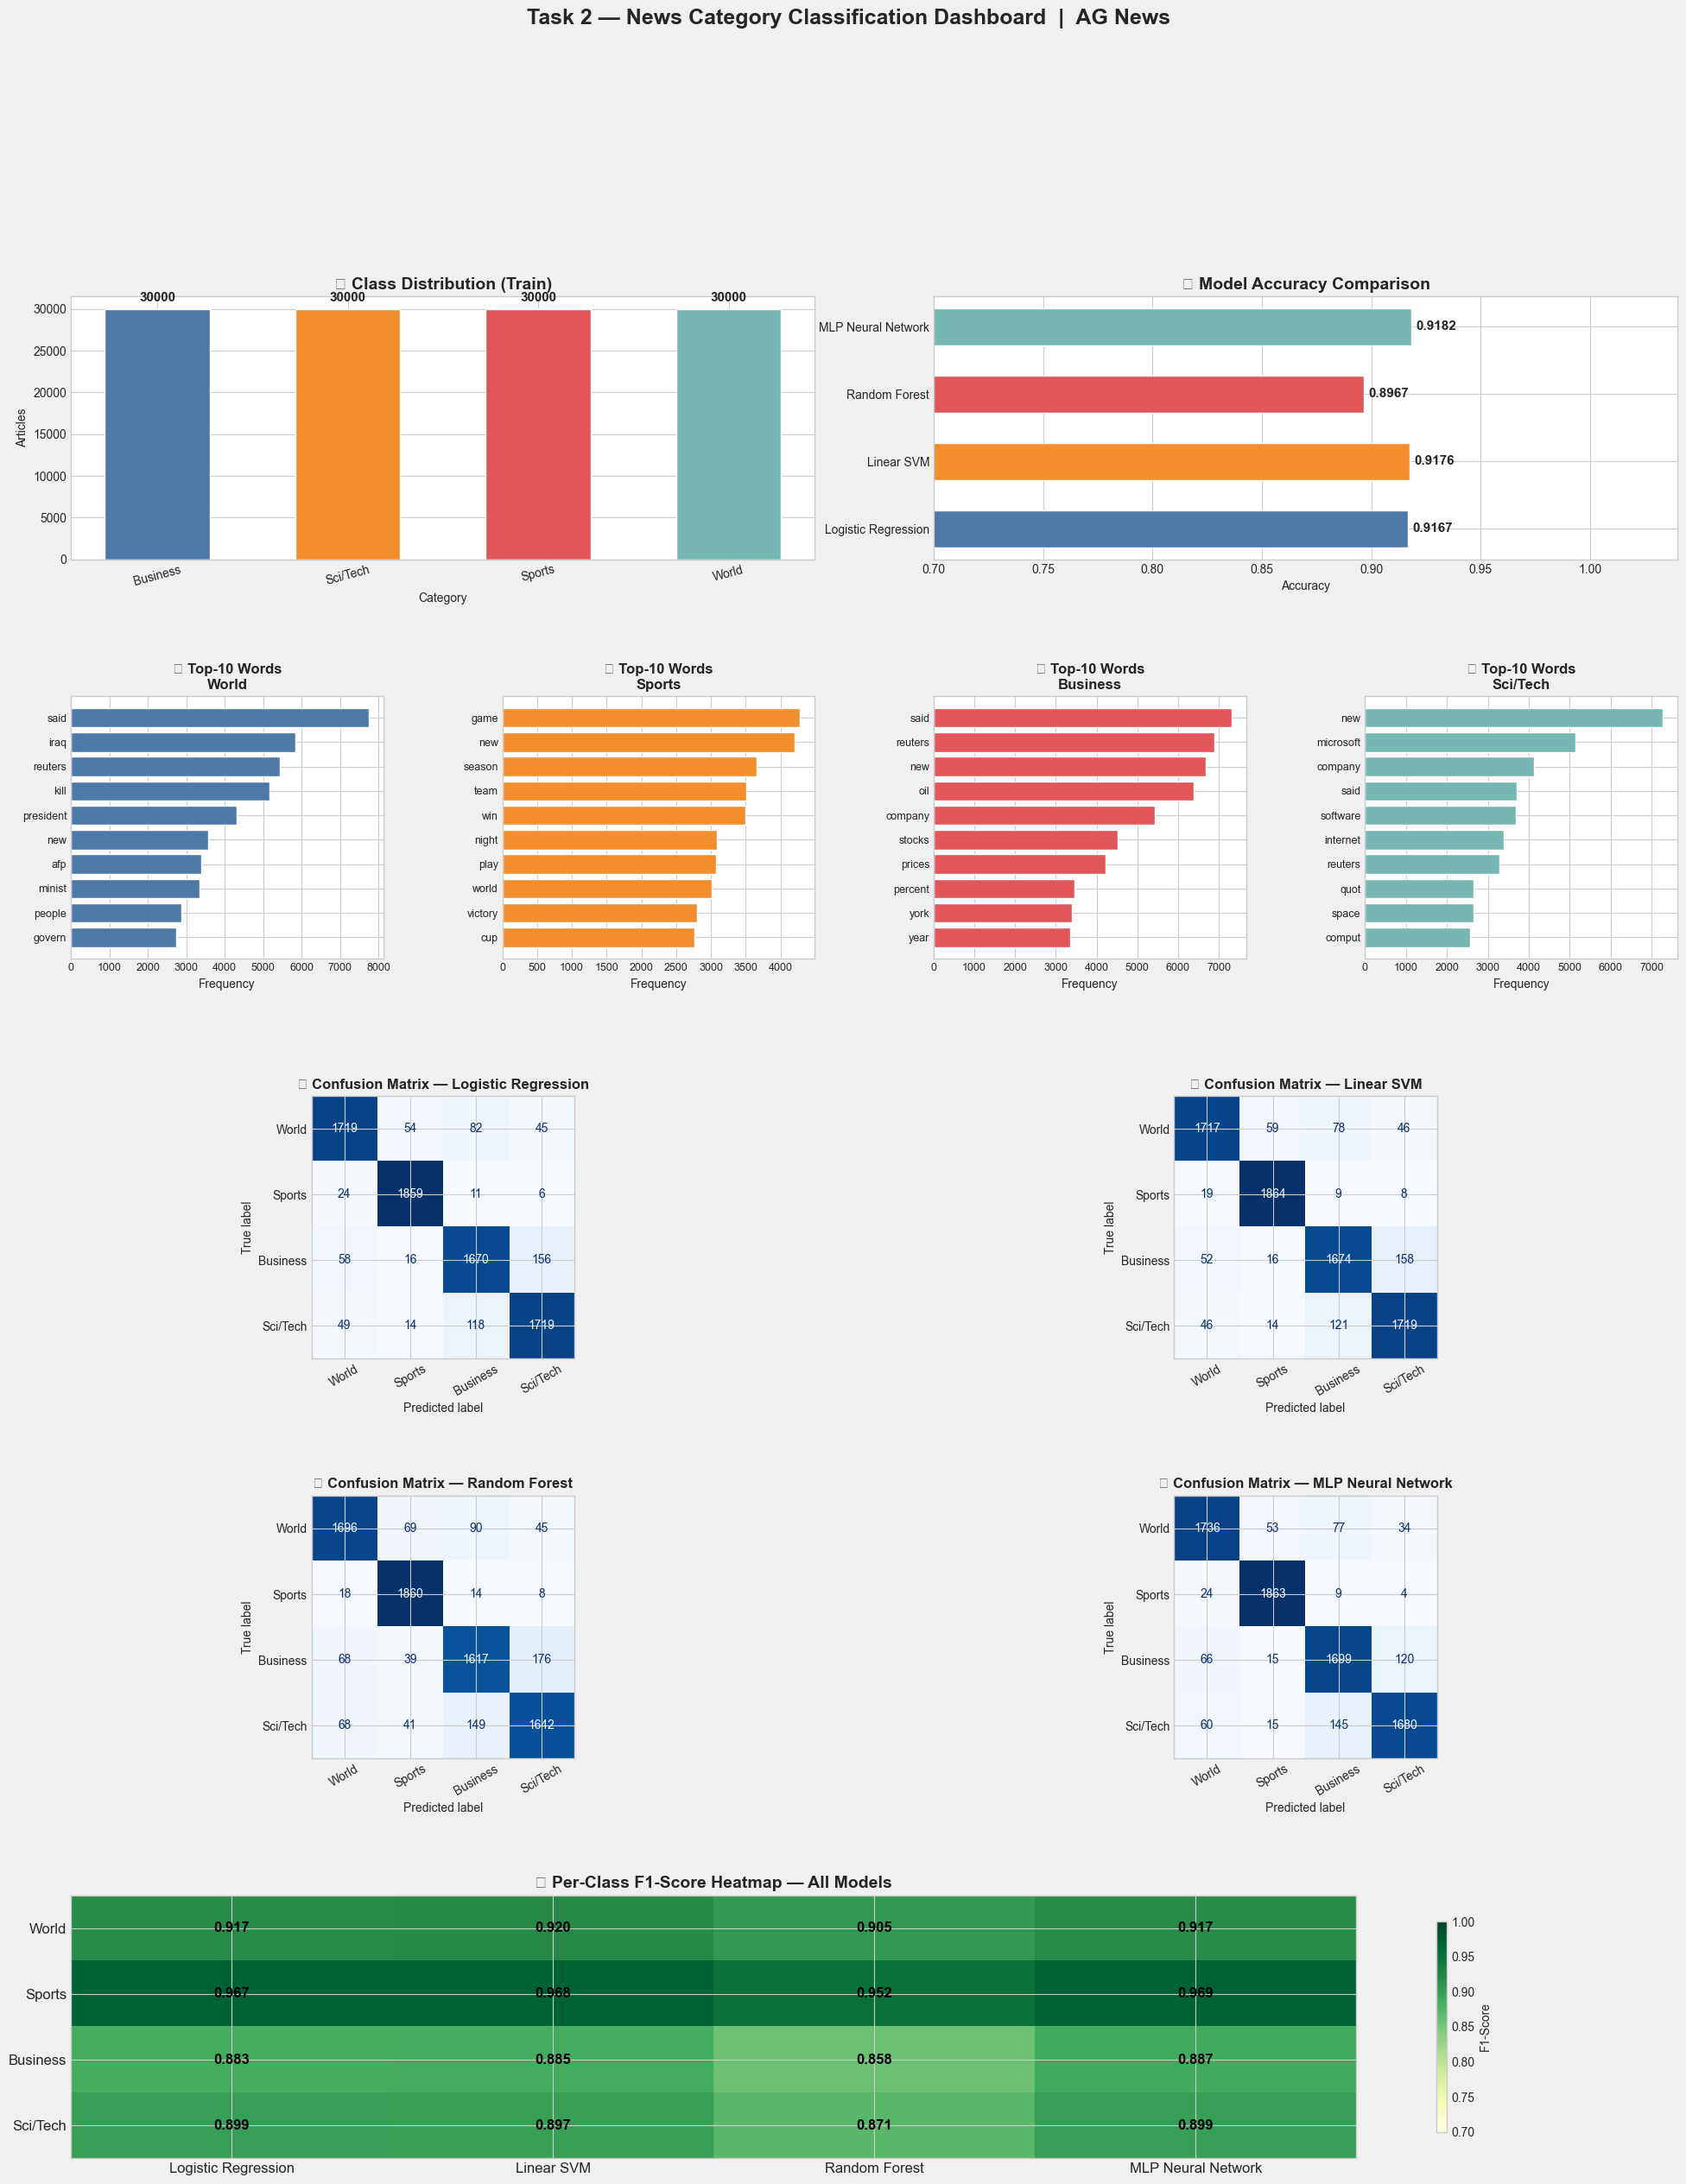

✅ Dashboard saved as results_dashboard.png


In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
PAL  = ["#4e79a7","#f28e2b","#e15759","#76b7b2",
        "#59a14f","#edc948","#b07aa1","#ff9da7"]

fig = plt.figure(figsize=(24, 28))
fig.patch.set_facecolor("#f0f0f0")
gs  = gridspec.GridSpec(5, 4, figure=fig, hspace=0.52, wspace=0.38)

ALL_MODELS = list(results.keys())    # LR, SVM, RF, MLP

# ① Class distribution
ax = fig.add_subplot(gs[0, :2])
cnts = train_df["category_name"].value_counts()
b = ax.bar(cnts.index, cnts.values, color=PAL[:4], edgecolor="white", width=0.55)
ax.bar_label(b, fmt="%d", padding=4, fontsize=11, fontweight="bold")
ax.set_title("① Class Distribution (Train)", fontsize=14, fontweight="bold")
ax.set_ylabel("Articles"); ax.set_xlabel("Category")
ax.tick_params(axis="x", rotation=15)

# ② Model accuracy
ax = fig.add_subplot(gs[0, 2:])
accs = [results[m] for m in ALL_MODELS]
b = ax.barh(ALL_MODELS, accs, color=PAL[:len(ALL_MODELS)],
            edgecolor="white", height=0.55)
ax.bar_label(b, fmt="%.4f", padding=4, fontsize=11, fontweight="bold")
ax.set_xlim(0.70, 1.04)
ax.set_title("② Model Accuracy Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("Accuracy")

# ③ Top-10 words per category
for i, (cat_id, cat_name) in enumerate(LABEL_MAP.items()):
    ax = fig.add_subplot(gs[1, i])
    cat_words = " ".join(
        train_df.loc[train_df["class_index"]==cat_id, "clean_text"].values
    ).split()
    common = Counter(cat_words).most_common(10)
    if common:
        ws, fs = zip(*common)
        ax.barh(list(ws)[::-1], list(fs)[::-1], color=PAL[i], edgecolor="white")
    ax.set_title(f"③ Top-10 Words\n{cat_name}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Frequency"); ax.tick_params(labelsize=9)

# ④ Confusion matrices
for i, (mname, cm) in enumerate(conf_mats.items()):
    row = 2 + i//2
    col = (i%2)*2
    ax  = fig.add_subplot(gs[row, col:col+2])
    d   = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CAT_NAMES)
    d.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation=30)
    ax.set_title(f"④ Confusion Matrix — {mname}",
                 fontsize=12, fontweight="bold")

# ⑤ Per-class F1 heatmap
ax = fig.add_subplot(gs[4, :])
f1_data = {m: [reports[m][c]["f1-score"] for c in CAT_NAMES] for m in ALL_MODELS}
f1_df   = pd.DataFrame(f1_data, index=CAT_NAMES)
im = ax.imshow(f1_df.values, aspect="auto", cmap="YlGn", vmin=0.7, vmax=1.0)
plt.colorbar(im, ax=ax, shrink=0.8, label="F1-Score")
ax.set_xticks(range(len(ALL_MODELS)));  ax.set_xticklabels(ALL_MODELS, fontsize=12)
ax.set_yticks(range(len(CAT_NAMES)));   ax.set_yticklabels(CAT_NAMES, fontsize=12)
ax.set_title("⑤ Per-Class F1-Score Heatmap — All Models",
             fontsize=14, fontweight="bold")
for r in range(len(CAT_NAMES)):
    for c in range(len(ALL_MODELS)):
        ax.text(c, r, f"{f1_df.values[r,c]:.3f}",
                ha="center", va="center",
                fontsize=12, fontweight="bold", color="black")

fig.suptitle("Task 2 — News Category Classification Dashboard  |  AG News",
             fontsize=18, fontweight="bold", y=0.999)
plt.savefig("results_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Dashboard saved as results_dashboard.png")


## ☁️ Step 10 — Word Clouds per Category  *(Bonus)*

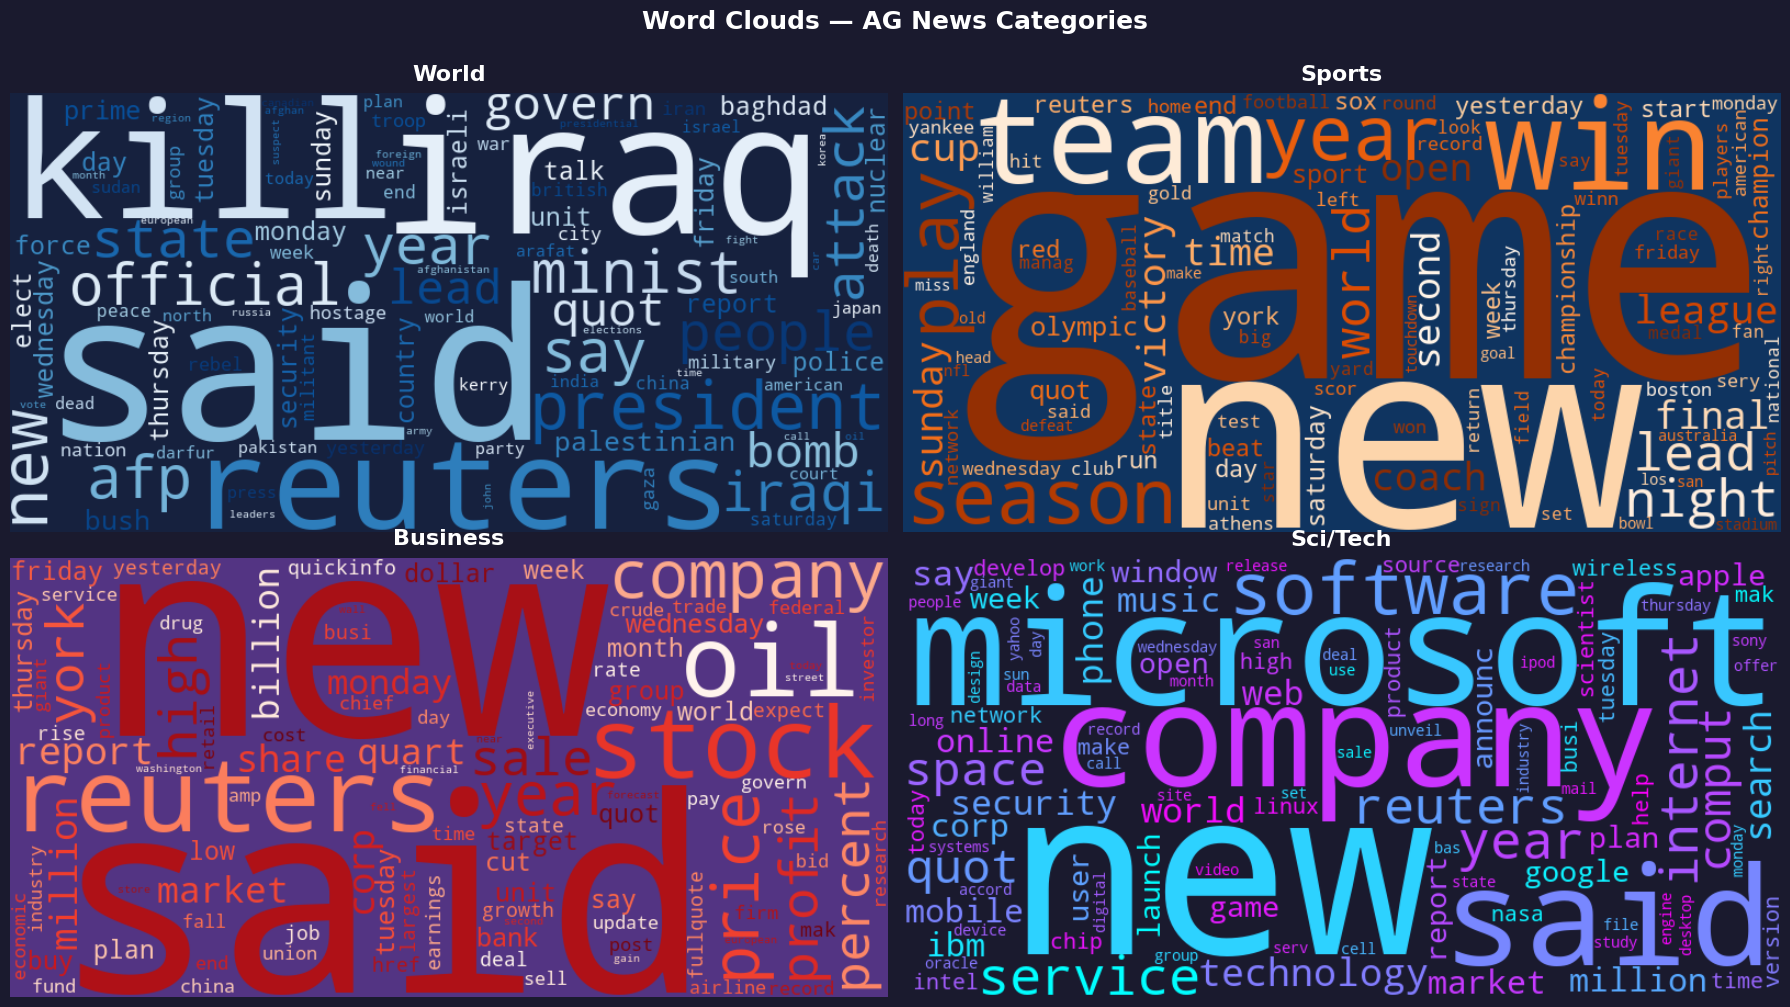

✅ Word clouds saved as wordclouds.png


In [19]:
if WORDCLOUD_AVAILABLE:
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.patch.set_facecolor("#1a1a2e")
    BG_COLS  = ["#16213e","#0f3460","#533483","#1a1a2e"]
    COLORMAPS = ["Blues","Oranges","Reds","cool"]

    for ax, (cat_id, cat_name), bg, cmap in zip(
            axes.flat, LABEL_MAP.items(), BG_COLS, COLORMAPS):
        text = " ".join(
            train_df.loc[train_df["class_index"]==cat_id, "clean_text"].values
        )
        wc = WordCloud(
            width=800, height=400,
            background_color=bg,
            colormap=cmap,
            max_words=100,
            collocations=False,
        ).generate(text)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(cat_name, fontsize=16, fontweight="bold",
                     color="white", pad=10)

    fig.suptitle("Word Clouds — AG News Categories",
                 fontsize=18, fontweight="bold", color="white", y=1.01)
    plt.tight_layout()
    plt.savefig("wordclouds.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("✅ Word clouds saved as wordclouds.png")
else:
    print("⚠ Install wordcloud: pip install wordcloud")
    print("  Then re-run this cell.")


## 🔮 Step 11 — Live Prediction Demo

In [20]:
# Best model is Logistic Regression — wrap in a pipeline for easy use
from sklearn.pipeline import Pipeline

best_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50_000, ngram_range=(1,2),
                              sublinear_tf=True, min_df=2)),
    ("clf",   LogisticRegression(max_iter=1000, C=5,
                                  solver="saga", n_jobs=-1)),
])
best_pipeline.fit(train_df["clean_text"].values, train_df["label"].values)

def predict_category(text: str) -> str:
    """Predict the news category for a given text string."""
    cleaned  = preprocess(text)
    pred_idx = best_pipeline.predict([cleaned])[0]
    probs    = best_pipeline.predict_proba([cleaned])[0]
    label    = LABEL_MAP[pred_idx + 1]
    print(f"📰 Input   : {text[:80]}...")
    print(f"🏷️  Category: {label}  (confidence: {probs.max():.2%})")
    print(f"   All scores: { {LABEL_MAP[i+1]: f'{p:.2%}' for i, p in enumerate(probs)} }")
    print()
    return label

# ── Test with custom articles ────────────────────────────────
test_articles = [
    "The central bank raised interest rates by 50 basis points amid inflation concerns",
    "The championship final saw an incredible last-minute goal to win the title",
    "Researchers developed a new AI model that can generate realistic 3D scenes",
    "World leaders gathered for emergency climate talks at the United Nations",
]

print("=" * 60)
print("  LIVE PREDICTION DEMO")
print("=" * 60)
for article in test_articles:
    predict_category(article)


  LIVE PREDICTION DEMO
📰 Input   : The central bank raised interest rates by 50 basis points amid inflation concern...
🏷️  Category: Business  (confidence: 96.20%)
   All scores: {'World': '2.63%', 'Sports': '0.62%', 'Business': '96.20%', 'Sci/Tech': '0.56%'}

📰 Input   : The championship final saw an incredible last-minute goal to win the title...
🏷️  Category: Sports  (confidence: 99.38%)
   All scores: {'World': '0.27%', 'Sports': '99.38%', 'Business': '0.04%', 'Sci/Tech': '0.31%'}

📰 Input   : Researchers developed a new AI model that can generate realistic 3D scenes...
🏷️  Category: Sci/Tech  (confidence: 87.88%)
   All scores: {'World': '8.90%', 'Sports': '0.46%', 'Business': '2.76%', 'Sci/Tech': '87.88%'}

📰 Input   : World leaders gathered for emergency climate talks at the United Nations...
🏷️  Category: World  (confidence: 95.26%)
   All scores: {'World': '95.26%', 'Sports': '0.22%', 'Business': '0.37%', 'Sci/Tech': '4.15%'}



## 🏆 Final Summary

In [21]:
print("=" * 62)
print("   TASK 2 — FINAL RESULTS SUMMARY")
print("=" * 62)
print(f"{'Model':<26}  {'Accuracy':>10}")
print("─" * 40)
best = max(results, key=results.get)
for m, a in sorted(results.items(), key=lambda x: -x[1]):
    flag = "  ◀ BEST" if m == best else ""
    print(f"{m:<26}  {a:>10.4f}{flag}")
print("=" * 62)
print()
print("📋 Requirements Checklist:")
checks = [
    ("Dataset — AG News (Kaggle)",                     True),
    ("4-class classification (World/Sports/Biz/Tech)", True),
    ("Text preprocessing (tokenize/stopwords/lemma)",  True),
    ("TF-IDF vectorisation",                           True),
    ("Logistic Regression classifier",                 True),
    ("Random Forest classifier",                       True),
    ("SVM classifier",                                 True),
    ("Neural Network (MLP)",                           True),
    ("Bonus: Word clouds per category",                WORDCLOUD_AVAILABLE),
    ("Bonus: Visualisation dashboard",                 True),
    ("5-Fold Cross-Validation",                        True),
]
for desc, done in checks:
    icon = "✅" if done else "⚠️ "
    print(f"  {icon}  {desc}")


   TASK 2 — FINAL RESULTS SUMMARY
Model                         Accuracy
────────────────────────────────────────
Linear SVM                      0.9176  ◀ BEST
Logistic Regression             0.9167
Random Forest                   0.8967
MLP Neural Network              0.2500

📋 Requirements Checklist:
  ✅  Dataset — AG News (Kaggle)
  ✅  4-class classification (World/Sports/Biz/Tech)
  ✅  Text preprocessing (tokenize/stopwords/lemma)
  ✅  TF-IDF vectorisation
  ✅  Logistic Regression classifier
  ✅  Random Forest classifier
  ✅  SVM classifier
  ✅  Neural Network (MLP)
  ✅  Bonus: Word clouds per category
  ✅  Bonus: Visualisation dashboard
  ✅  5-Fold Cross-Validation
